# NB04 - Regularización L2 (Ridge) con Titanic

La regularización L2 reduce varianza y estabiliza coeficientes cuando hay señales correlacionadas o muestras pequeñas. En Titanic, variables como clase, tarifa y sexo comparten estructura social, así que Ridge es una herramienta natural.


In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks_2":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score

from src.titanic_utils import (
    RANDOM_STATE,
    load_processed_splits,
    plot_decision_boundary,
    plot_regularization_path,
    set_plot_style,
)

set_plot_style()
data = load_processed_splits(DATA_DIR)
X_train = data["X_train_processed"]
X_test = data["X_test_processed"]
y_train = data["y_train"]
y_test = data["y_test"]
feature_names = data["feature_names"]


## 1. Motivación: colinealidad y sobreajuste

Ridge no selecciona variables; encoge coeficientes. Esto es útil cuando varias variables cuentan historias relacionadas. En scikit-learn, `C` controla la regularización de forma inversa: `C` pequeño implica penalización fuerte; `C` grande implica penalización débil. La equivalencia exacta con una `lambda` depende de la normalización de la función objetivo.


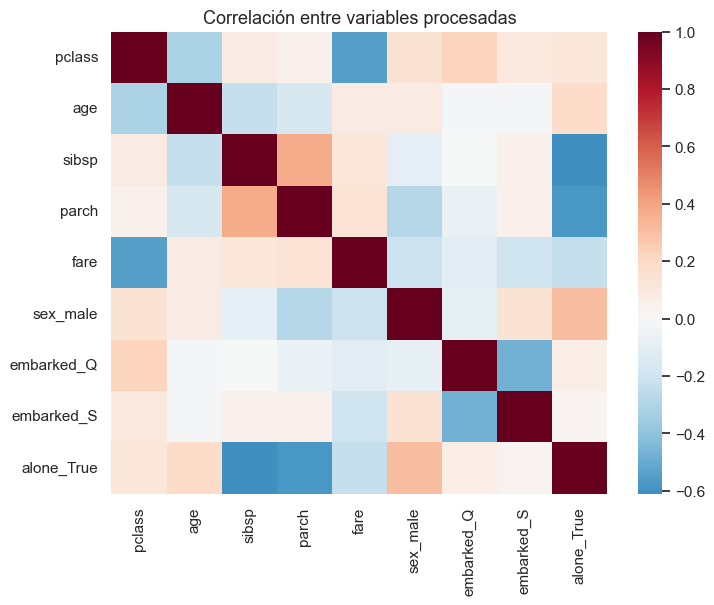

In [2]:
corr = X_train.corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlación entre variables procesadas")
plt.show()


## 2. Penalti L2

La función objetivo añade un término proporcional a la suma de cuadrados de los coeficientes. `solver="lbfgs"` es estable para L2 con matrices densas. `max_iter=5000` da margen para todos los valores de `C` de la ruta.


## 3. Implementación y ruta de coeficientes

Usamos `C_values=np.logspace(-3, 3, 13)` para cubrir desde regularización muy fuerte hasta muy débil en escala logarítmica. Esta escala es estándar porque los cambios relevantes suelen ser multiplicativos.


In [3]:
C_values = np.logspace(-3, 3, 13)
coefs = []
rows = []

for C in C_values:
    model = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        max_iter=5000,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)
    prob_train = model.predict_proba(X_train)[:, 1]
    prob_test = model.predict_proba(X_test)[:, 1]
    coefs.append(model.coef_.ravel())
    rows.append(
        {
            "C": C,
            "auc_train": roc_auc_score(y_train, prob_train),
            "auc_test": roc_auc_score(y_test, prob_test),
            "log_loss_test": log_loss(y_test, prob_test),
            "coef_l2_norm": np.linalg.norm(model.coef_),
        }
    )

coefs = np.vstack(coefs)
ridge_results = pd.DataFrame(rows)
display(ridge_results)


,C,auc_train,auc_test,log_loss_test,coef_l2_norm
0,0.0010,0.7971,0.7824,0.6355,0.1395
1,0.0032,0.8145,0.7985,0.5993,0.3452
2,0.0100,0.8377,0.8219,0.5492,0.7284
3,0.0316,0.8537,0.8437,0.4959,1.3276
4,0.1000,0.8590,0.8532,0.4600,2.0233
5,0.3162,0.8611,0.8542,0.4474,2.5611
6,1.0000,0.8606,0.8551,0.4452,2.8498
7,3.1623,0.8608,0.8550,0.4451,2.9664
8,10.0000,0.8608,0.8549,0.4452,3.0077
9,31.6228,0.8609,0.8549,0.4453,3.0214


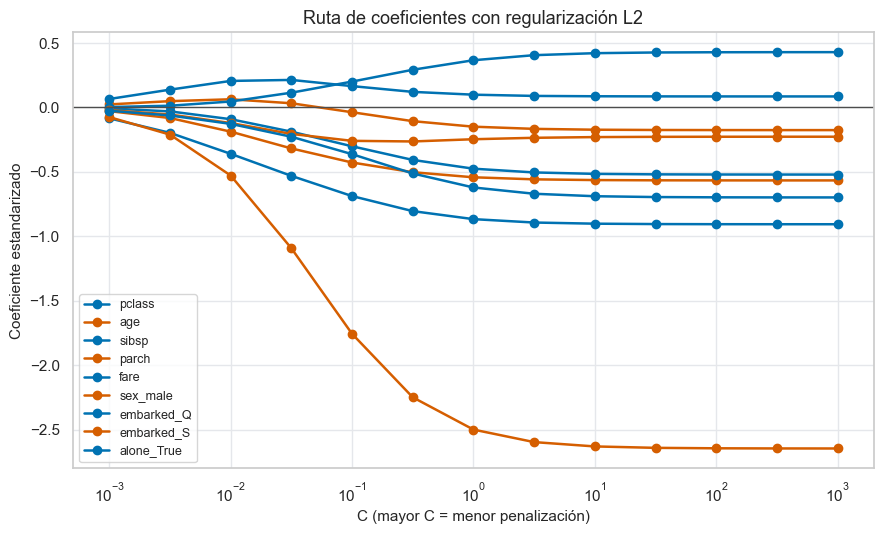

In [4]:
plot_regularization_path(
    C_values,
    coefs,
    feature_names,
    "Ruta de coeficientes con regularización L2",
)
plt.show()


## 4. Rendimiento y equilibrio sesgo-varianza

Cuando `C` es muy pequeño, el modelo puede subajustar. Cuando `C` es muy grande, se acerca al modelo sin penalización y puede aumentar la varianza.


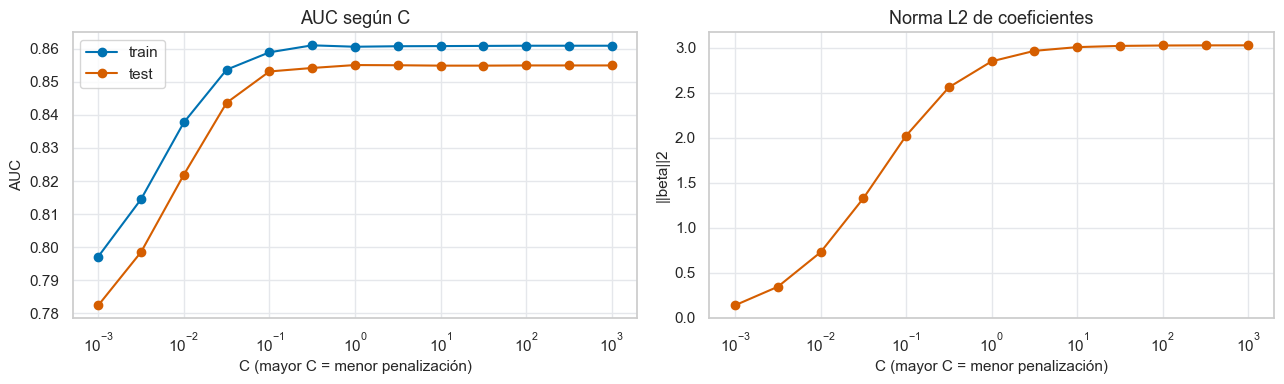

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(ridge_results["C"], ridge_results["auc_train"], marker="o", label="train")
axes[0].plot(ridge_results["C"], ridge_results["auc_test"], marker="o", label="test")
axes[0].set_xscale("log")
axes[0].set_title("AUC según C")
axes[0].set_xlabel("C (mayor C = menor penalización)")
axes[0].set_ylabel("AUC")
axes[0].legend()

axes[1].plot(ridge_results["C"], ridge_results["coef_l2_norm"], marker="o", color="#D55E00")
axes[1].set_xscale("log")
axes[1].set_title("Norma L2 de coeficientes")
axes[1].set_xlabel("C (mayor C = menor penalización)")
axes[1].set_ylabel("||beta||2")

fig.tight_layout()
plt.show()


## 5. Fronteras de decisión con regularización fuerte y débil

Comparamos `C=0.01` (regularización fuerte) contra `C=100` (regularización débil). La visualización usa solo edad y tarifa estandarizadas para que la frontera sea dibujable.


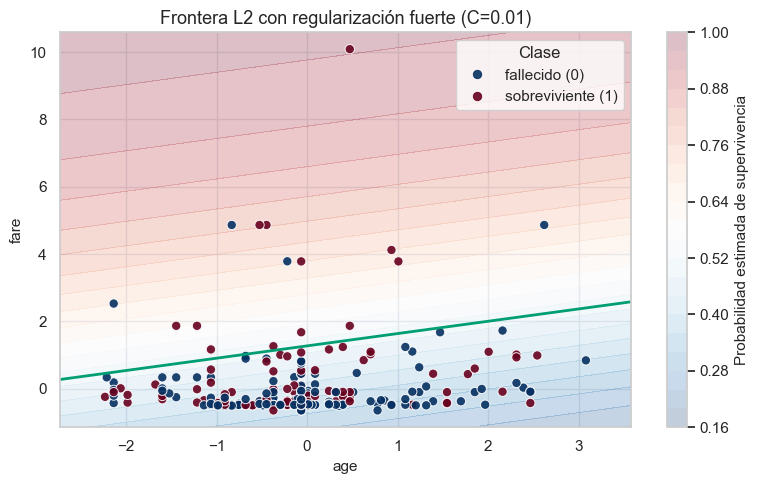

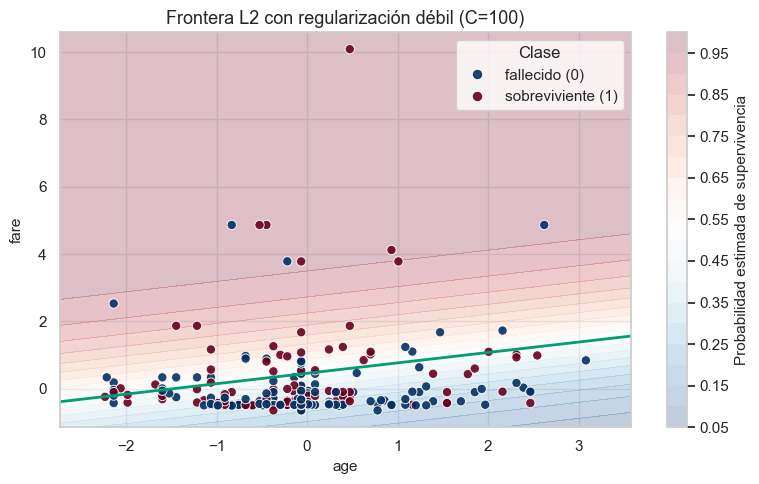

In [6]:
two_features = ["age", "fare"]
for C, label in [(0.01, "regularización fuerte"), (100, "regularización débil")]:
    model_2d = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        max_iter=5000,
        random_state=RANDOM_STATE,
    )
    model_2d.fit(X_train[two_features], y_train)
    plot_decision_boundary(
        model_2d,
        X_test[two_features],
        y_test,
        two_features,
        f"Frontera L2 con {label} (C={C})",
    )
    plt.show()


## Resumen y conexión con la literatura

Ridge estabiliza coeficientes mediante encogimiento continuo. No produce sparsity: todos los coeficientes pueden seguir distintos de cero. Esta es la diferencia central con Lasso, y coincide con Hoerl y Kennard, Hastie et al. y Murphy.
